<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/Data_Trasformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [21]:
df = pd.read_csv('/content/adult_with_headers (1).csv')

In [22]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [23]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [24]:
df.duplicated().sum()

np.int64(24)

In [25]:
df.drop_duplicates(inplace = True)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
num_cols = df.select_dtypes(include=['int', 'float']).columns
cat_cols = df.select_dtypes(include='object').columns


In [28]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df['fnlwgt'] = mm.fit_transform(df[['fnlwgt']])


In [29]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
df[num_cols] = ss.fit_transform(df[num_cols])

min max scaling technique is used on a numerical column for normalization.
It give range from 0 to 1, by evaluating the minimum and maximum values of that feature.



standard scaling is apply on numerical columns only

In [30]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,0.148292,-0.216743,-0.035664,United-States,<=50K
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145975,-0.216743,-2.222483,United-States,<=50K
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145975,-0.216743,-0.035664,Cuba,<=50K


In [31]:
df = pd.get_dummies(df,columns=['sex'],dtype='int')

In [32]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,0.148292,-0.216743,-0.035664,United-States,<=50K,0,1
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,-0.145975,-0.216743,-2.222483,United-States,<=50K,0,1
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,-0.145975,-0.216743,-0.035664,United-States,<=50K,0,1
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,-0.145975,-0.216743,-0.035664,United-States,<=50K,0,1
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,-0.145975,-0.216743,-0.035664,Cuba,<=50K,1,0


In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns = ['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'native_country', 'income']

for col in columns:
  df[col] = le.fit_transform(df[col])

In [34]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
0,0.030390,7,-1.063569,9,1.134777,4,1,1,4,0.148292,-0.216743,-0.035664,39,0,0,1
1,0.836973,6,-1.008668,9,1.134777,2,4,0,4,-0.145975,-0.216743,-2.222483,39,0,0,1
2,-0.042936,4,0.245040,11,-0.420679,0,6,1,4,-0.145975,-0.216743,-0.035664,39,0,0,1
3,1.056950,4,0.425752,1,-1.198407,2,6,0,2,-0.145975,-0.216743,-0.035664,39,0,0,1
4,-0.776193,4,1.408066,9,1.134777,2,10,5,2,-0.145975,-0.216743,-0.035664,5,0,1,0


In [35]:
df.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,income,sex_ Female,sex_ Male
count,3.253700e+04,32537.000000,3.253700e+04,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,3.253700e+04,3.253700e+04,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,-7.555945e-17,3.868734,-5.481336e-17,10.297507,2.849858e-17,2.611427,6.572856,1.446538,3.665827,3.646945e-17,4.367598e-19,-6.485884e-17,36.721579,0.240926,0.330762,0.669238
std,1.000015e+00,1.456445,1.000015e+00,3.870142,1.000015e+00,1.506301,4.229521,1.607064,0.848847,1.000015e+00,1.000015e+00,1.000015e+00,7.820732,0.427652,0.470495,0.470495
min,-1.582777e+00,0.000000,-1.681551e+00,0.000000,-3.531590e+00,0.000000,0.000000,0.000000,0.000000,-1.459754e-01,-2.167432e-01,-3.194403e+00,0.000000,0.000000,0.000000,0.000000
25%,-7.761933e-01,4.000000,-6.816726e-01,9.000000,-4.206787e-01,2.000000,3.000000,0.000000,4.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,39.000000,0.000000,0.000000,0.000000
50%,-1.162616e-01,4.000000,-1.082361e-01,11.000000,-3.181473e-02,2.000000,7.000000,1.000000,4.000000,-1.459754e-01,-2.167432e-01,-3.566374e-02,39.000000,0.000000,0.000000,1.000000
75%,6.903217e-01,4.000000,4.472760e-01,12.000000,7.459132e-01,4.000000,10.000000,3.000000,4.000000,-1.459754e-01,-2.167432e-01,3.693028e-01,39.000000,0.000000,1.000000,1.000000
max,3.770003e+00,8.000000,1.226778e+01,15.000000,2.301369e+00,6.000000,14.000000,5.000000,4.000000,1.338964e+01,1.058963e+01,4.742941e+00,41.000000,1.000000,1.000000,1.000000


In [36]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
capital_gain,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32537 non-null  float64
 1   workclass       32537 non-null  int64  
 2   fnlwgt          32537 non-null  float64
 3   education       32537 non-null  int64  
 4   education_num   32537 non-null  float64
 5   marital_status  32537 non-null  int64  
 6   occupation      32537 non-null  int64  
 7   relationship    32537 non-null  int64  
 8   race            32537 non-null  int64  
 9   capital_gain    32537 non-null  float64
 10  capital_loss    32537 non-null  float64
 11  hours_per_week  32537 non-null  float64
 12  native_country  32537 non-null  int64  
 13  income          32537 non-null  int64  
 14  sex_ Female     32537 non-null  int64  
 15  sex_ Male       32537 non-null  int64  
dtypes: float64(6), int64(10)
memory usage: 4.2 MB


One-Hot Encoding :
The categorical feature is nominal (no natural order), such as Gender, City, or Color.
You're using algorithms like Logistic Regression, Linear Regression, SVM, KNN, or Neural Networks.

Label Encoding :
The feature is ordinal (e.g., Low < Medium < High), or
You're using tree-based models such as Decision Trees, Random Forest, XGBoost, or LightGBM, which generally do not rely on the numeric ordering in the same way as distance- or coefficient-based models.

<Axes: >

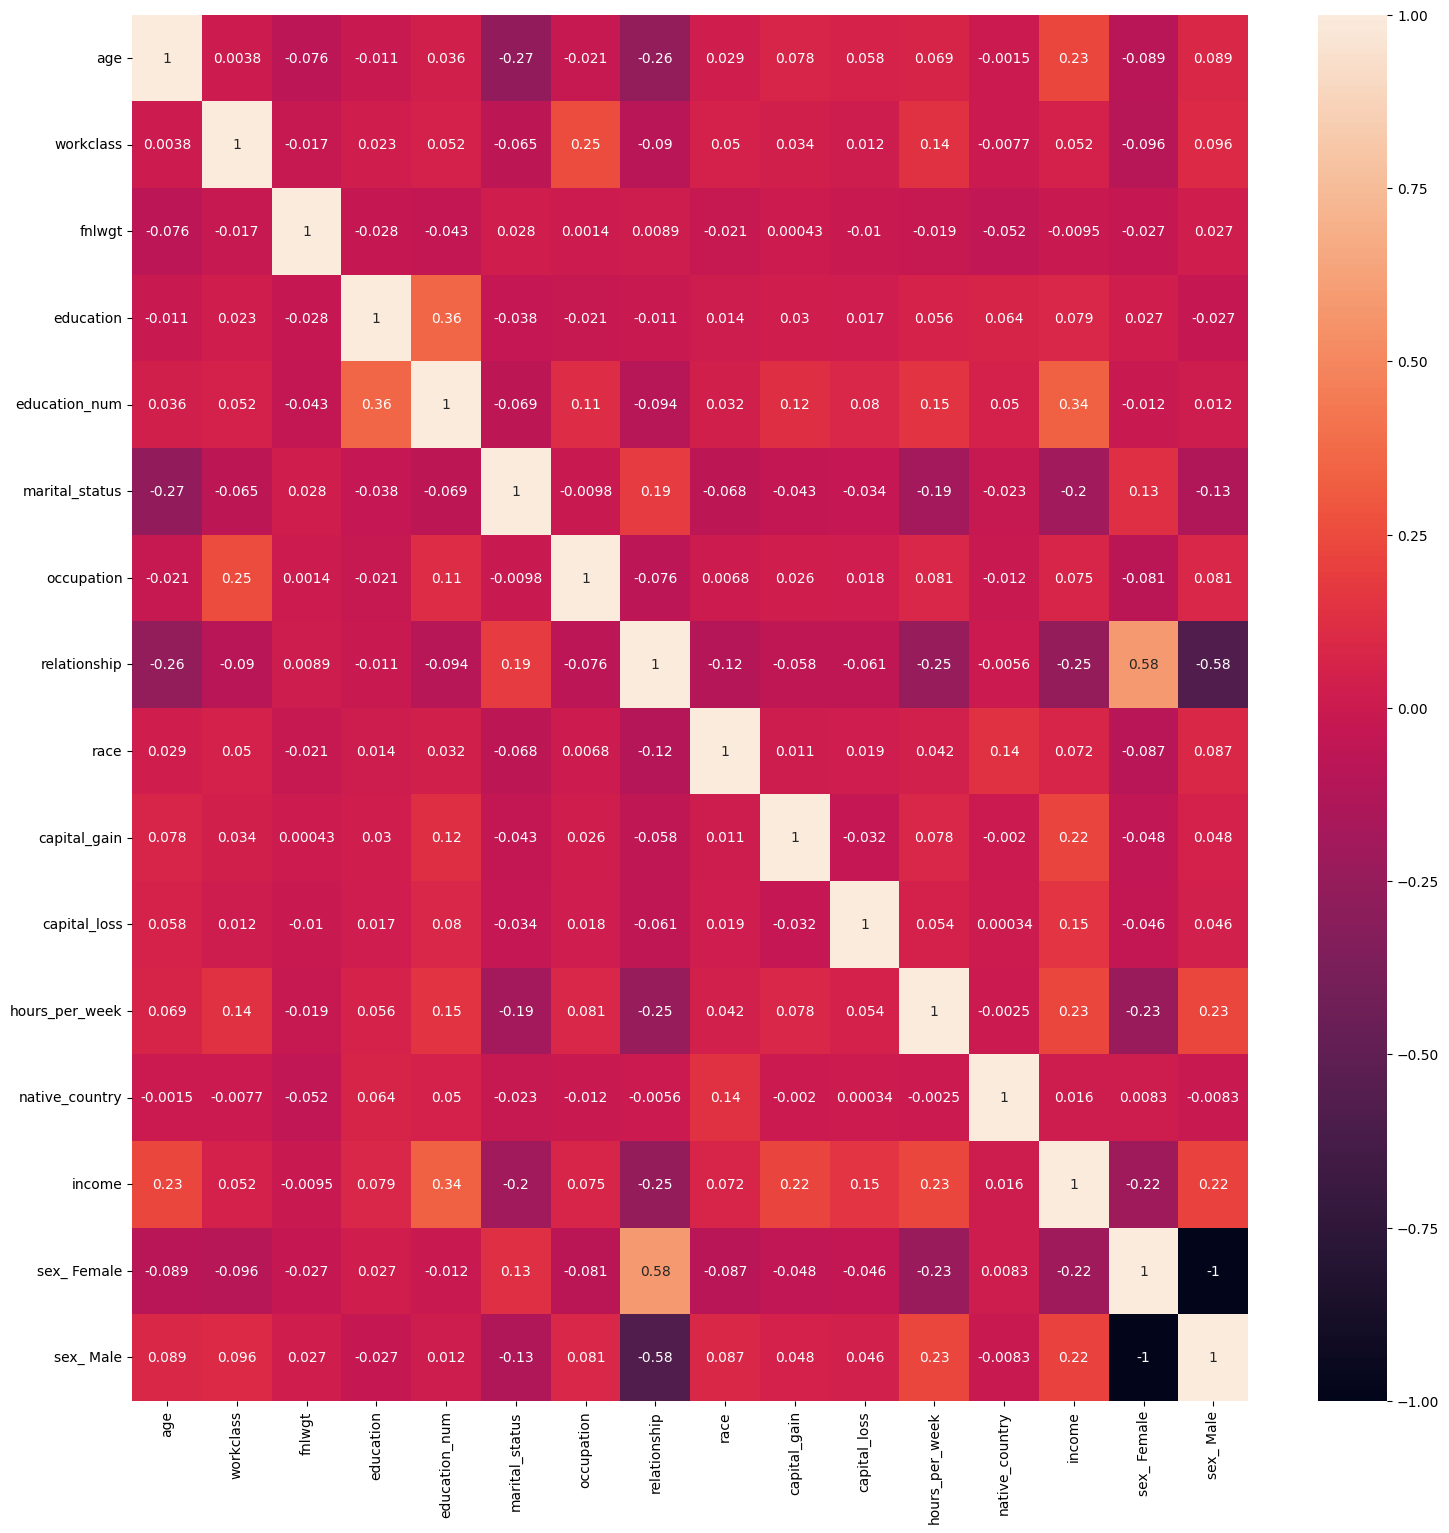

In [38]:
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

Feature engineering


In [39]:
df['total_capital'] = df['capital_gain'] - df['capital_loss']

In [40]:
df['hours_per_age'] = df['hours_per_week'] / df['age']

In [41]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

df['capital_loss_log'] = np.log1p(df['capital_loss'])

df['total_capital_log'] = np.log1p(df['total_capital'])

df['fnlwgt_log'] = np.log1p(df['fnlwgt'])


In [43]:
df.drop(['capital_gain', 'capital_loss', 'total_capital'], axis=1, inplace=True)

df.drop('fnlwgt', axis=1, inplace=True)

In [44]:
df.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,hours_per_week,native_country,income,sex_ Female,sex_ Male,hours_per_age,capital_gain_log,capital_loss_log,total_capital_log,fnlwgt_log
0,0.030390,7,9,1.134777,4,1,1,4,-0.035664,39,0,0,1,-1.173537,0.138275,-0.244295,0.311180,NaN
1,0.836973,6,9,1.134777,2,4,0,4,-2.222483,39,0,0,1,-2.655381,-0.157795,-0.244295,0.068376,NaN
2,-0.042936,4,11,-0.420679,0,6,1,4,-0.035664,39,0,0,1,0.830629,-0.157795,-0.244295,0.068376,0.219168
3,1.056950,4,1,-1.198407,2,6,0,2,-0.035664,39,0,0,1,-0.033742,-0.157795,-0.244295,0.068376,0.354699
4,-0.776193,4,9,1.134777,2,10,5,2,-0.035664,5,0,1,0,0.045947,-0.157795,-0.244295,0.068376,0.878824


In [46]:
num_cols = ['age','education_num','hours_per_week','hours_per_age',
                 'capital_gain_log','capital_loss_log','total_capital_log','fnlwgt_log']


for col in num_cols:
    print(col, df[col].skew())

age 0.5576631514973125
education_num -0.30950025998999
hours_per_week 0.22875887785250423
hours_per_age 2.2437353306011274
capital_gain_log 5.898421757252234
capital_loss_log 4.3619017832978075
total_capital_log 5.679081873114274
fnlwgt_log -1.513475715115746
